In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
np.random.seed(42)
n_samples = 200
size = np.random.uniform(1000, 3000, n_samples)
bedrooms = np.random.randint(2, 6, n_samples)
age = np.random.uniform(0, 30, n_samples)

true_intercept = 50000
true_coef_size = 150
true_coef_bedrooms = 20000
true_coef_age = -2000

noise = np.random.normal(0,30000, n_samples)
price = (true_intercept +
         true_coef_size * size +
         true_coef_bedrooms * bedrooms +
         true_coef_age * age +
         noise )

df = pd.DataFrame({
    "Size": size,
    "Bedrooms": bedrooms,
    "Age": age,
    "Price": price
})
df.head()

,Size,Bedrooms,Age,Price
0,1749.080238,5,1.550452,419513.811657
1,2901.428613,5,15.940639,609618.139205
2,2463.987884,4,16.219054,495672.790392
3,2197.316968,2,19.122897,364044.641499
4,1312.037281,5,21.782740,276287.671969


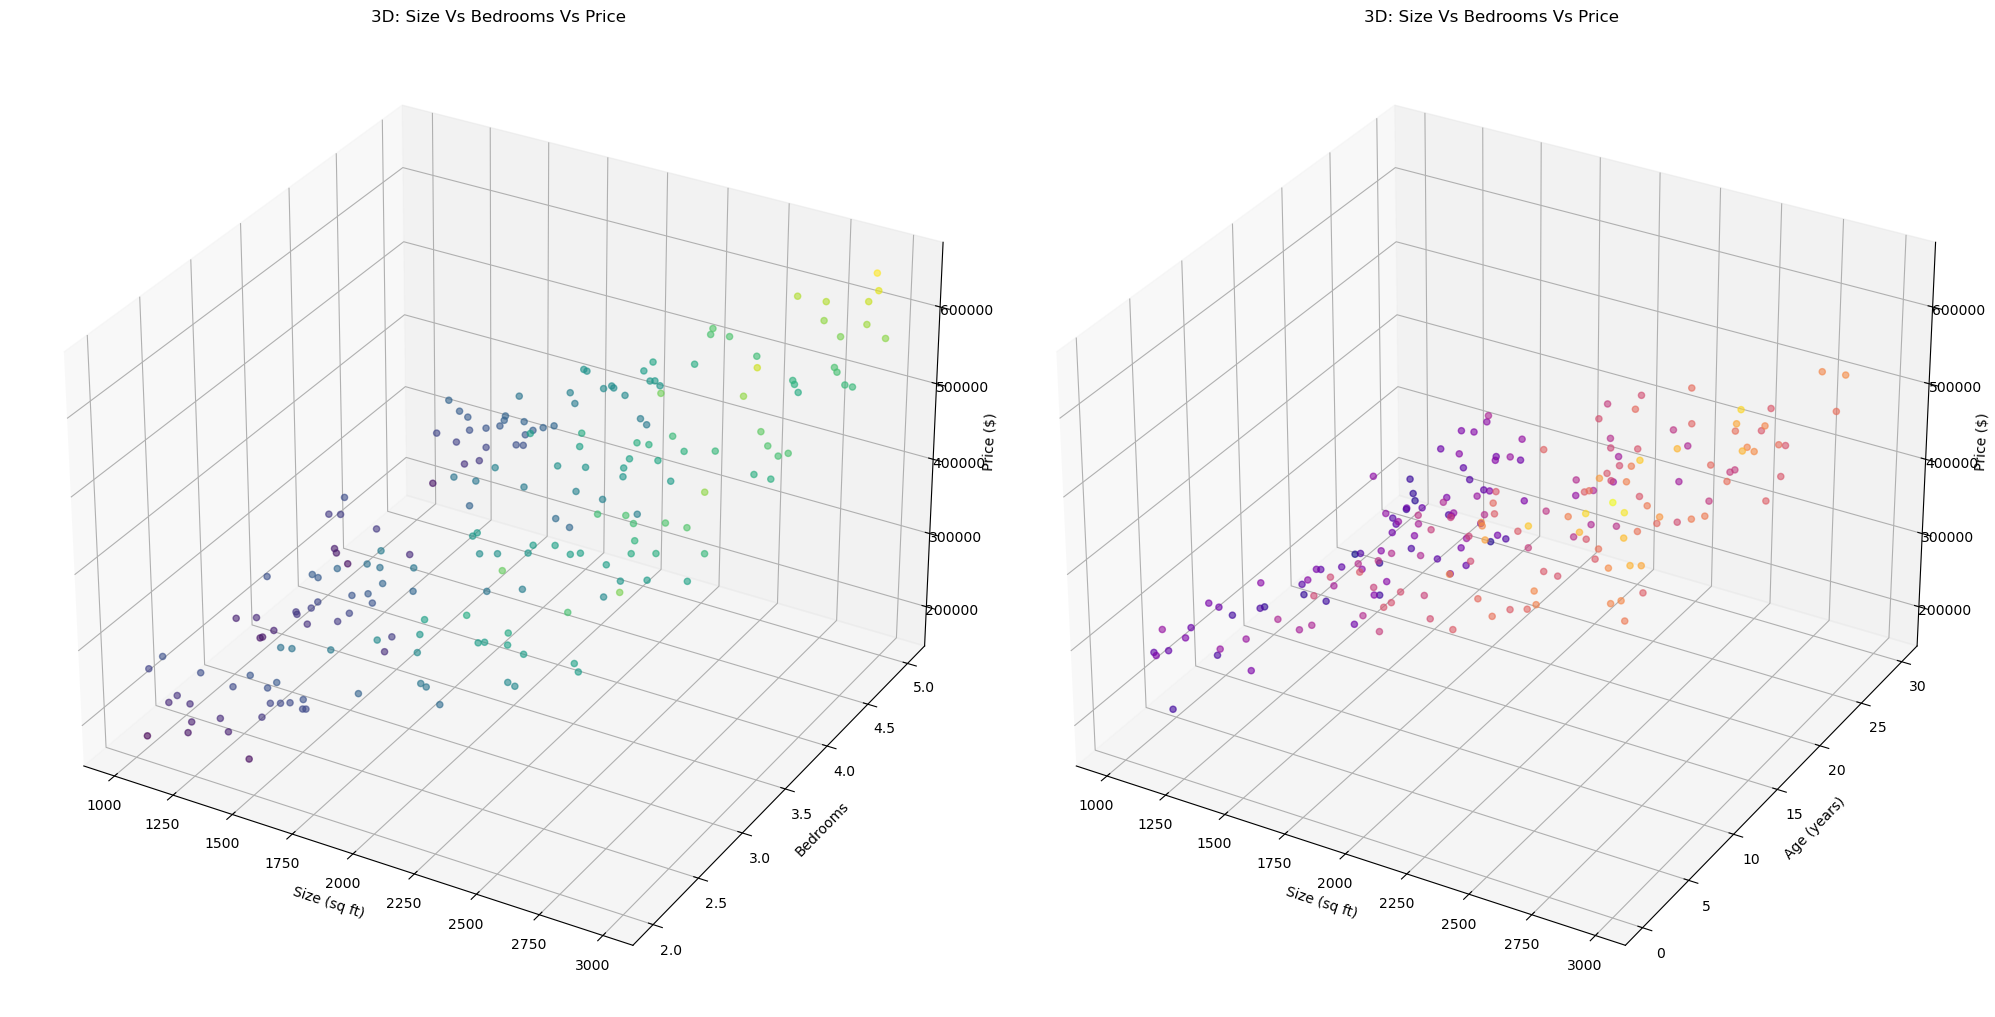

In [5]:
fig1 = plt.figure(figsize = (20, 16))

# 3D plot: Size Vs Bedrooms Vs Price 
ax_3d1 = fig1.add_subplot(1, 2, 1, projection = "3d")
ax_3d1.scatter(size, bedrooms, price, c = price, cmap = "viridis",  alpha = 0.6)
ax_3d1.set_xlabel("Size (sq ft)")
ax_3d1.set_ylabel("Bedrooms")
ax_3d1.set_zlabel("Price ($)")
ax_3d1.set_title("3D: Size Vs Bedrooms Vs Price")

ax_3d2 = fig1.add_subplot(1, 2, 2, projection = "3d")
ax_3d2.scatter(size, age, price, c = price, cmap = "plasma", alpha = 0.6)
ax_3d2.set_xlabel("Size (sq ft)")
ax_3d2.set_ylabel("Age (years)")
ax_3d2.set_zlabel("Price ($)")
ax_3d2.set_title("3D: Size Vs Bedrooms Vs Price")

plt.tight_layout()

In [7]:
""" 

Gradient Descent:
1. Start with random coefficients 
2. Calculate the error (cost function)
3. Update coefficients in the direction that reduces error
4. Repeat until convergence 

"""

' \n\nGradient Descent:\n1. Start with random coefficients \n2. Calculate the error (cost function)\n3. Update coefficients in the direction that reduces error\n4. Repeat until convergence \n\n'

In [9]:
X = df[["Size", "Bedrooms", "Age"]].values
y = df["Price"].values #1D array so one set of brackets

print(f"Shape of Feature Matrix {X.shape}")
print(f"Shape of Price {y.shape}")

Shape of Feature Matrix (200, 3)
Shape of Price (200,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (
    X, y, 
    test_size = 0.2, 
    random_state = 2
)

In [23]:
print(X_train.shape)
print(y_train.shape)

(160, 3)
(160,)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()

X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.reshape(-1,1)).flatten()

In [33]:
class MultipleRegression():
    def __init__(self, iterations = 1000, learning_rate = 0.01):
        self.iterations = iterations
        self.lr = learning_rate
        self.w = None  # We have multiple features, not just a scalar value
        self.b = 0  #This could be a scalar value, only one intercept
        self.cost_history = []

    def fit(self, X_train_scaled, y_train_scaled):
        n, n_features = X_train_scaled.shape
        self.w = np.zeros(n_features)
        self.b = 0
        for iteration in range(self.iterations):
            

            # Cost function
            y_pred = np.dot(X_train_scaled, self.w) + self.b
            cost =  np.sum((y_pred - y_train_scaled) **2) / (2 *n)
            self.cost_history.append(cost)

            error = (y_pred - y_train_scaled)
            gradient_w = (2/n) * np.dot(X_train_scaled.T, error)
            gradient_b = (2/n) * np.sum(error)

            self.w -= self.lr * gradient_w
            self.b -= self.lr * gradient_b

            if iteration % 100 == 0:
                print(f"Iteration {iteration}: Cost = {cost:.2f}")

    def predict(self, X_train_scaled):
        return np.dot(X_train_scaled, self.w) + self.b
    

model = MultipleRegression(iterations = 1000, learning_rate = 0.01)
model.fit(X_train_scaled, y_train_scaled)

Iteration 0: Cost = 0.50
Iteration 100: Cost = 0.04
Iteration 200: Cost = 0.04
Iteration 300: Cost = 0.04
Iteration 400: Cost = 0.04
Iteration 500: Cost = 0.04
Iteration 600: Cost = 0.04
Iteration 700: Cost = 0.04
Iteration 800: Cost = 0.04
Iteration 900: Cost = 0.04
